In [18]:
# Upload the codebase into the input folder, this ensures that
# the Python interpreter can load python files from within it.

import sys
sys.path.append('/kaggle/input/datasets/jasminestuart/uowaisecurity-codebase')  # change the parameter to your path if it's different
sys.path.append('/kaggle/input/datasets/jasminestuart/uowaisecurity-codebase/codebase')  # change the parameter to your path if it's different

In [19]:
import torch
import sys

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

print('PyTorch Version:', torch.__version__)
print('-' * 60)
if torch.cuda.is_available():
    print('CUDA Device Count:', torch.cuda.device_count())
    print('CUDA Device Name:')
    for i in range(torch.cuda.device_count()):
        print('\t', torch.cuda.get_device_name(i))
    print('CUDA Current Device Index:', torch.cuda.current_device())
    print('-' * 60)

print(f"Python version = {sys.version}")


PyTorch Version: 2.10.0+cu128
------------------------------------------------------------
CUDA Device Count: 2
CUDA Device Name:
	 Tesla T4
	 Tesla T4
CUDA Current Device Index: 0
------------------------------------------------------------
Python version = 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [20]:
# As usual, a bit of setup
import matplotlib.pyplot as plt
import types
from pathlib import Path
import logging
logging.getLogger().setLevel(logging.INFO)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

exp_cfg = types.SimpleNamespace()
exp_cfg.data_dir = Path(f"/kaggle/working/data")
exp_cfg.out_dir = Path(f"/kaggle/working/out")

exp_cfg.data_dir.mkdir(parents=True, exist_ok=True)
exp_cfg.out_dir.mkdir(parents=True, exist_ok=True)

exp_cfg.device = torch.device('cuda:0')  # use the first GPU


# Task 1/2: Grey-box Adversarial Examples (Total: 8 marks)

You will implement grey-box adversarial examples to fool a pretrained target model. Please download the target model from https://uowmailedu-my.sharepoint.com/:u:/g/personal/wzong_uow_edu_au/EWHR470-0khEs2gqOdAAZOMBHI7_KWubdkiJCD4pNpiCRQ?e=tra4CC

Unzip the file and upload the "target_model" folder to the input folder.
The following code will load the target model and evaluate its performance.

In this task, you have partial knowlegde about this target:
- The architecture of the target model is VGG (vgg11_bn).
- This model was trained in exactly the same way as we trained VGG models for the CW attack lab task.

Given 100 images that can be correctly recognized by the target model, you need to generate **targeted** adversarial examples for each image.
Adversarial perturbations are constrained by $L_{∞} \le 0.04$.

To generate adversarial examples, you need to implement the function **generate_greybox_ae** in the corresponding cell below.
Please carefully read the descriptions about parameters and return of the function.
You cannot use the target model, or its copy, to calculate any gradients.


Marks:
- 6 marks if fooling rate > 80%.
- 4 marks if fooling rate > 60%.
- 2 marks if fooling rate > 40%.
- 1 mark if fooling rate > 20%.
- 0 marks otherwise.

## Hints

One potential solution is to follow the successful targeted black-box attack strategy we have discussed in the lecture. By including the knowledge about the target model (e.g., its architecture, training data, etc.), you can generate targeted grey-box attacks.

You can try both CW and PGD attacks, and choose the one that performs well for this task. You may need to explore effective attack parameters for achieving full marks.

You can load a copy of the target model in your function and access its predictions, i.e., observing pairs of input and output. although this is not necessary for implementing grey-box attacks.

However, you are **NOT** allowed to use the target model, or its copy, to calculate any gradients. Such behaviors will result in **0 marks** for the coding part.


## Loading images
Run the cell below to load 100 clean images that can be correctly recognized by the target model. These images will be saved in x_arr in the unnormalized form.

INFO:root:loading check point from file: /kaggle/input/models/jasminestuart/a1targetmodel/pytorch/default/1/target_model/saved_epoch-49.tar, epoch_check = 49
evaluating test set: loss 1.01394; accuracy 0.8722;: 100%|██████████| 157/157 [00:01<00:00, 94.48it/s] 


Accuracy of the target model on x_arr = 100.0%


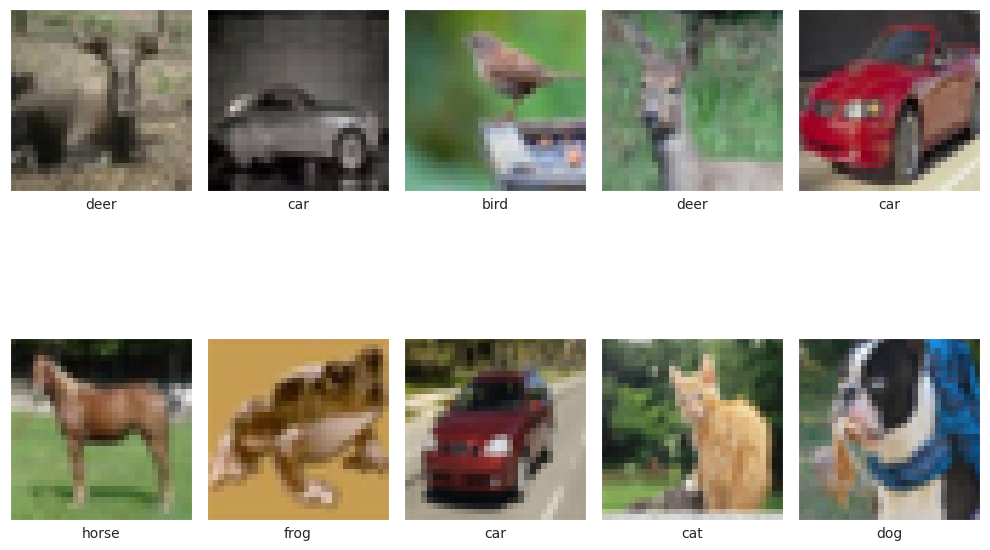

In [21]:
import numpy as np

import torchvision
import torchvision.transforms as transforms

from codebase import model_trainer, utils, setup
from codebase.classifiers import vgg

# input to this model must be normalized
cifar10_mean_tensor = torch.Tensor(setup.CIFAR10_MEAN).reshape([1, 3, 1, 1]).to(exp_cfg.device)
cifar10_std_tensor = torch.Tensor(setup.CIFAR10_STD).reshape([1, 3, 1, 1]).to(exp_cfg.device)

# specify the directory of target model.
# change it to your directory if different
target_ckpt_dir = Path("/kaggle/input/models/jasminestuart/a1targetmodel/pytorch/default/1/target_model")

# load the pretrained target model
dic_saved = model_trainer.ModelTrainer.load_latest_ckpt(target_ckpt_dir)
assert dic_saved is not None, "Cannot find pretrained weights."
target_model = vgg.vgg11_bn(num_classes=10).to(exp_cfg.device)
target_model.load_state_dict(dic_saved["model_state"])
target_model.eval()

# evaluate it on the normalized testing set.
# the accuracy should be 0.8722.
test_set = torchvision.datasets.CIFAR10(
        root=str(exp_cfg.data_dir), train=False,
        download=True, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
        ])
)

model_trainer.ModelTrainer.eval_on_dset(target_model, test_set)

# create a test set that is NOT normalized for extracting clean images
unnormalized_test_set = torchvision.datasets.CIFAR10(
    root=str(exp_cfg.data_dir), train=False,
    download=True, transform=transforms.Compose([transforms.ToTensor()])
)

# randomly get 100 images that are correctly recognized by the target model
rand_idxes = np.random.RandomState(375).permutation(len(unnormalized_test_set))
x_arr, y_arr = [], []

for idx in rand_idxes:
    # randomly get one
    test_x, test_y = unnormalized_test_set[idx]
    test_x = test_x.to(exp_cfg.device)
    assert isinstance(test_y, int)  # test_x is Tensor while test_y is simply an integer

    pred = target_model(utils.normalize(test_x.unsqueeze(0), cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    if pred.item() == test_y:
        x_arr.append(test_x)
        y_arr.append(test_y)

    if len(x_arr) >= 100:
        break
assert len(x_arr) == 100, "Cannot find enough correctly predicted clean images."

x_arr = torch.stack(x_arr).to(exp_cfg.device)
y_arr = torch.LongTensor(y_arr).to(exp_cfg.device)

# Before generating any attacks, let's check the predictions on x_arr.
preds = target_model(utils.normalize(x_arr, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
acc = (preds == y_arr).sum() / len(y_arr)
print(f"Accuracy of the target model on x_arr = {acc * 100:.1f}%")

# show some clean images
utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=x_arr, labels_arr=y_arr, class_names=setup.CIFAR10_CLASSES)

## Implement generate_greybox_ae (6 marks)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [24]:
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from pathlib import Path

from codebase import model_trainer, utils, setup
from codebase.classifiers import vgg


def generate_greybox_ae(
        x_arr: torch.Tensor,
        y_arr: torch.Tensor,
        adv_target_arr: torch.Tensor,
        adv_l_inf: float,
        exp_cfg,
) -> torch.Tensor:
    """
    x_arr: unnormalized clean images with shape [N, C, H, W].
    y_arr: ground truth labels with shape [N].
    adv_target_arr: the target labels of adversarial examples with shape [N].
    adv_l_inf: the allowed l_inf for all adversarial examples.
    exp_cfg: general configurations including out_dir, data_dir, device, etc.

    return: adversarial examples with shape [N, C, H, W] that can fool the target model.
    """

    #get the right device 
    device = exp_cfg.device
    original_device = x_arr.device
    #move the inputs to the correct device
    x_arr = x_arr.to(device)
    adv_target_arr = adv_target_arr.to(device)
    #move the cigar10 normalization tensors to the device aswell
    mean = cifar10_mean_tensor.to(device)
    std = cifar10_std_tensor.to(device)

    #like the cw lab train or load multiple surrogate models
    surrogate_models = _load_or_train_surrogate_ensemble(exp_cfg, num_models=3)

    #store different attack candidates generated on the surrogates
    candidate_list = []

    candidate_list.append(
        _targeted_ensemble_pgd(
            models=surrogate_models,
            x_arr=x_arr,
            adv_target_arr=adv_target_arr,
            adv_l_inf=adv_l_inf,
            mean=mean,
            std=std,
            steps=120,
            step_size=0.001,
            restarts=4,
            use_margin=False,
        )
    )

    candidate_list.append(
        _targeted_ensemble_pgd(
            models=surrogate_models,
            x_arr=x_arr,
            adv_target_arr=adv_target_arr,
            adv_l_inf=adv_l_inf,
            mean=mean,
            std=std,
            steps=180,
            step_size=0.0008,
            restarts=3,
            use_margin=True,
        )
    )

    #choose the best candidate for each image using target model predictions
    best_adv = x_arr.clone()
    best_margin = torch.full((x_arr.shape[0],), -1e9, device=device)

    target_model.eval()
    with torch.no_grad():
        for cand in candidate_list:
            logits = target_model(utils.normalize(cand, mean, std))
            margins = _target_margin(logits, adv_target_arr)

            better_mask = margins > best_margin
            best_margin[better_mask] = margins[better_mask]
            best_adv[better_mask] = cand[better_mask]

    return best_adv.detach().to(original_device)


def _load_or_train_surrogate_ensemble(exp_cfg, num_models=3):
    device = exp_cfg.device

    #define the training set assign
    train_set = torchvision.datasets.CIFAR10(
        root=str(exp_cfg.data_dir),
        train=True,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD),
        ])
    )

    #define the test set for evaluation during the training
    test_set = torchvision.datasets.CIFAR10(
        root=str(exp_cfg.data_dir),
        train=False,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD),
        ])
    )

    model_list = []
    ensemble_root = Path("/kaggle/working/greybox_surrogate_ensemble/run_2")
    ensemble_root.mkdir(parents=True, exist_ok=True)

    #train or load several surrogate models
    for i in range(num_models):
        ckpt_dir = ensemble_root.joinpath(f"ckpt_model_{i}")

        trainer_cfg = model_trainer.ModelTrainerConfig(
            batch_size=128,
            test_batch_size=128,
            num_workers=4,
            test_every=None,
            train_drop_last=True,
            loss_func=model_trainer.cross_entropy_loss,
            is_classifier=True,
            max_epochs=20,
            lr=1e-3,
            lr_gamma=0.1,
            lr_step_size=[40],
            ckpt_dir=ckpt_dir,
        )

        #create a vg11-bn surrogate model
        model = vgg.vgg11_bn(num_classes=10).to(device)

        trainer = model_trainer.ModelTrainer(
            model=model,
            train_set=train_set,
            test_set=test_set,
            config=trainer_cfg,
        )

        #if checkpoint exists it will be loaded otherwise the model wil be trained
        trainer.run()
        model.eval()
        model_list.append(model)

    return model_list


def _ensemble_logits(models, norm_x):
    #average logits from all the surrogate models in the ensemble
    logits_sum = None
    for model in models:
        logits = model(norm_x)
        if logits_sum is None:
            logits_sum = logits
        else:
            logits_sum = logits_sum + logits
    return logits_sum / len(models)


def _targeted_ensemble_pgd(
        models,
        x_arr,
        adv_target_arr,
        adv_l_inf,
        mean,
        std,
        steps,
        step_size,
        restarts,
        use_margin,
):
    device = x_arr.device

    #store the best adversarial example found for each image
    best_adv = x_arr.clone()
    best_score = torch.full((x_arr.shape[0],), -1e9, device=device)

    #use multiple random restarts to improve the success of the attack
    for _ in range(restarts):
        #start from a random point within the allowed range
        adv_x = x_arr + torch.empty_like(x_arr).uniform_(-adv_l_inf, adv_l_inf)
        adv_x = torch.clamp(adv_x, 0.0, 1.0)

        #iteratively update adversarial images
        for _ in range(steps):
            adv_x.requires_grad_(True)

            #normalise inputs before feeding them into the surrogate ensemble
            norm_adv = utils.normalize(adv_x, mean, std)
            logits = _ensemble_logits(models, norm_adv)

            # cross-entropy loss pushes predictions toward the target labels
            ce_loss = F.cross_entropy(logits, adv_target_arr)

            #add a cwstyle margin loss
            if use_margin:
                margin_loss = _cw_targeted_margin_loss(logits, adv_target_arr, confidence=0.0)
                loss = ce_loss + 0.5 * margin_loss
            else:
                loss = ce_loss

            #clear the previous gradients
            for model in models:
                model.zero_grad(set_to_none=True)
            if adv_x.grad is not None:
                adv_x.grad.zero_()

            #compute gradients using the surrogate models
            loss.backward()

            with torch.no_grad():
                #targeted pgd moves opposite to the gradient direction
                adv_x = adv_x - step_size * adv_x.grad.sign()
                #project perturbations back into the allowed l_inf range
                delta = torch.clamp(adv_x - x_arr, min=-adv_l_inf, max=adv_l_inf)
                #keep pixel values in the valid range
                adv_x = torch.clamp(x_arr + delta, 0.0, 1.0)

        with torch.no_grad():
            #score the result using the target margin on the surrogate ensemble
            logits = _ensemble_logits(models, utils.normalize(adv_x, mean, std))
            score = _target_margin(logits, adv_target_arr)

            #keep the best result for each image
            better_mask = score > best_score
            best_score[better_mask] = score[better_mask]
            best_adv[better_mask] = adv_x[better_mask]

    return best_adv.detach()


def _cw_targeted_margin_loss(logits, target_labels, confidence=0.0):
    #get the logit value of the target class
    batch_idx = torch.arange(logits.shape[0], device=logits.device)
    target_logits = logits[batch_idx, target_labels]

    #get the largest logit among the non target classes
    other_logits = logits.clone()
    other_logits[batch_idx, target_labels] = -1e9
    max_other_logits = other_logits.max(dim=1).values

    #the targeted margin loss encourages the target logit to be larger
    loss = torch.clamp(max_other_logits - target_logits + confidence, min=0.0)
    return loss.mean()


def _target_margin(logits, target_labels):
    #calculate the gap between the target logit and the largest other logit
    batch_idx = torch.arange(logits.shape[0], device=logits.device)
    target_logits = logits[batch_idx, target_labels]

    other_logits = logits.clone()
    other_logits[batch_idx, target_labels] = -1e9
    max_other_logits = other_logits.max(dim=1).values

    return target_logits - max_other_logits

The cell below will evaluates your implementation and print out your marks for this part.

training: epoch 1 / 20; iter 390; lr 1.00e-03; loss 1.79187; accuracy 0.28464;: 100%|██████████| 390/390 [00:18<00:00, 21.30it/s]
training: epoch 2 / 20; iter 390; lr 1.00e-03; loss 1.33331; accuracy 0.51034;: 100%|██████████| 390/390 [00:18<00:00, 20.55it/s]
training: epoch 3 / 20; iter 390; lr 1.00e-03; loss 1.03787; accuracy 0.64347;: 100%|██████████| 390/390 [00:18<00:00, 21.18it/s]
training: epoch 4 / 20; iter 390; lr 1.00e-03; loss 0.86155; accuracy 0.70992;: 100%|██████████| 390/390 [00:18<00:00, 21.62it/s]
training: epoch 5 / 20; iter 390; lr 1.00e-03; loss 0.74598; accuracy 0.75549;: 100%|██████████| 390/390 [00:17<00:00, 21.68it/s]
training: epoch 6 / 20; iter 390; lr 1.00e-03; loss 0.65135; accuracy 0.78834;: 100%|██████████| 390/390 [00:18<00:00, 21.48it/s]
training: epoch 7 / 20; iter 390; lr 1.00e-03; loss 0.57766; accuracy 0.81164;: 100%|██████████| 390/390 [00:18<00:00, 21.25it/s]
training: epoch 8 / 20; iter 390; lr 1.00e-03; loss 0.51779; accuracy 0.83361;: 100%|█████

Maximum l_inf = 0.04
Grey-box adversarial examples fooling rate = 81.0%


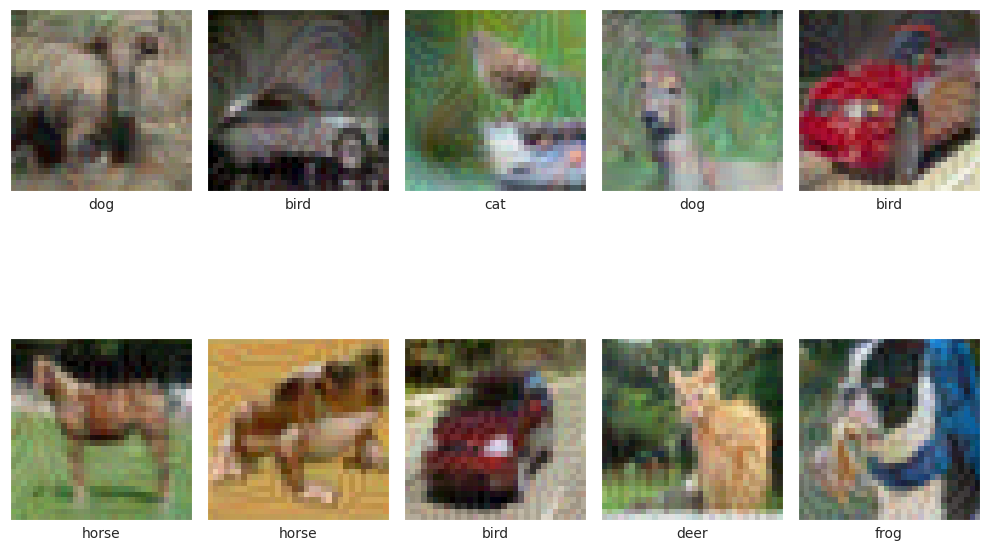


******* Your marks for generating grey-box adversarial examples is 6. *******



In [25]:
# generate grey-box adversarial examples using your function
adv_l_inf = 0.04
# choose target label as the next label.
adv_target_arr = (y_arr + 1) % len(setup.CIFAR10_CLASSES)

adv_x = generate_greybox_ae(
    x_arr=x_arr, y_arr=y_arr, adv_target_arr=adv_target_arr, adv_l_inf=adv_l_inf, exp_cfg=exp_cfg
)
assert target_model.training is False, "Your function should not change the training state."

# check the quality of adv_x
cal_adv_l_inf = torch.abs(adv_x - x_arr).max().item()
print(f"Maximum l_inf = {cal_adv_l_inf:.2f}")
if (cal_adv_l_inf > adv_l_inf + 1e-4) or (adv_x.max().item() > 1.0) or (adv_x.min().item() < 0.0):
    print("At least one adversarial example does not fulfill the requirement.")
    adv_marks = 0
else:
    # get marks if achieving ceratin fooling rate
    with torch.no_grad():
        adv_preds = target_model(utils.normalize(adv_x, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    fooling_rate = (adv_preds == adv_target_arr).sum() / len(adv_target_arr)
    fooling_rate = fooling_rate.item()
    print(f"Grey-box adversarial examples fooling rate = {fooling_rate * 100:.1f}%")

    if fooling_rate > 0.80:
        adv_marks = 6
    elif fooling_rate > 0.60:
        adv_marks = 4
    elif fooling_rate > 0.40:
        adv_marks = 2
    elif fooling_rate > 0.20:
        adv_marks = 1
    else:
        adv_marks = 0

    utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=adv_x, labels_arr=adv_preds, class_names=setup.CIFAR10_CLASSES)
print(f"\n******* Your marks for generating grey-box adversarial examples is {adv_marks}. *******\n")

## Briefly describe how you implemented the grey-box adversarial examples. (2 marks)

Your answer: I started by training an ensemble of surrogate models that matched the known information about the traget model such as its architecture and that the same training setup was was used in the week 2 lab. since I couldnt calculate gradients on the real target model, the surrogate ensemble was used to generate transferable targeted adversarial examples instead. For the attack I used a targeted ensemble pgd appraoch with multiple random restarts. I added small random noise within the allowed bound then repeatedly updated the adversarial images useing gradients from the surrogates. I generated two different atatck candidates with different settings and once both of them were generated I used the real target models predictions only to compare them and selected the best candidate for each image based on the target margin. the final output is a set of targeted adversarial examples taht are generated using surrogate gradients and then selected based on which candidate transfered best to the target model. 

# Task 2/2: Universal Adversarial Perturbations (Total: 7 marks)

You will implement universal adversarial perturbations (UAPs) to fool a pretrained target model.
You will use the same target model from Task 1/2 to complete this task.
This is a white-box attack so that you have full access to the target model.

You are given 100 images that can be correctly recognized by the target model.
You need to generate UAPs that can be added to all these 100 images to fool the target model to output 3 (i.e., "cat").
UAPs are constrained by $L_{∞} \le 0.06$.

To generate UAPs, you need to implement the function **generate_UAPs** in the corresponding cell below.
Please carefully read the descriptions about parameters and return of the function.

Marks:
- 5 marks if fooling rate > 90%.
- 3 marks if fooling rate > 70%.
- 1 mark if fooling rate > 50%.
- 0 marks otherwise.

## Implement generate_UAPs (5 marks)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [26]:
import torch
import torch.nn.functional as F
import utils


def generate_UAPs(
        target_model: torch.nn.Module,
        x_arr: torch.Tensor,
        y_arr: torch.Tensor,
        UAP_target: int,
        UAP_l_inf: float,
        exp_cfg,
) -> torch.Tensor:
    """
    target_model: the target model we want to fool.
    x_arr: unnormalized clean images with shape [N, C, H, W].
    y_arr: ground truth labels with shape [N].
    UAP_target: the target label.
    UAP_l_inf: the allowed l_inf for the UAP.
    exp_cfg: general configurations including out_dir, data_dir, device, etc.

    return: UAP with shape [C, H, W] that can fool the target model
            when added to many images.
    """

    #get the device used by the target model
    device = next(target_model.parameters()).device
    target_model.eval() #keep the model in evaluation mode 

    #move input images to the same device as the model
    x_arr = x_arr.to(device)
    #move Ccifar-10 normalization tensors to the same device
    mean = cifar10_mean_tensor.to(device)
    std = cifar10_std_tensor.to(device)

    #initialize one shared perturbation for all of the images
    uap = torch.empty(
        (1, x_arr.shape[1], x_arr.shape[2], x_arr.shape[3]),
        device=device
    ).uniform_(-UAP_l_inf, UAP_l_inf)

    #enable gradient updates for the perturbation
    uap.requires_grad_(True)

    #create the same target label for all of the images
    target_labels = torch.full(
        (x_arr.shape[0],),
        fill_value=UAP_target,
        dtype=torch.long,
        device=device
    )

    optimizer = torch.optim.Adam([uap], lr=0.01) #optimize only the uap

    #training settings
    batch_size = 20
    num_steps = 300

    #repeatedly update the shared perturbation
    for step in range(num_steps):
        #shuffle image order each step
        perm = torch.randperm(x_arr.shape[0], device=device)

        for start in range(0, x_arr.shape[0], batch_size):
            #get the current batch
            idx = perm[start:start + batch_size]
            batch_x = x_arr[idx]
            batch_target = target_labels[idx]

            #add the same perturbation to every image in the batch
            adv_x = torch.clamp(batch_x + uap, min=0.0, max=1.0)

            #normalize before passing into the model
            adv_x = utils.normalize(adv_x, mean, std)

            logits = target_model(adv_x)

            #targeted loss, push the predictions toward the target label
            loss = F.cross_entropy(logits, batch_target)

            #optimisation step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            #keep within the allowed bound
            with torch.no_grad():
                uap.clamp_(-UAP_l_inf, UAP_l_inf)

    return uap.detach().squeeze(0)

The cell below will evaluate your implementation and print out your marks for this part.

UAPs l_inf = 0.06
UAPs fooling rate = 93.0%


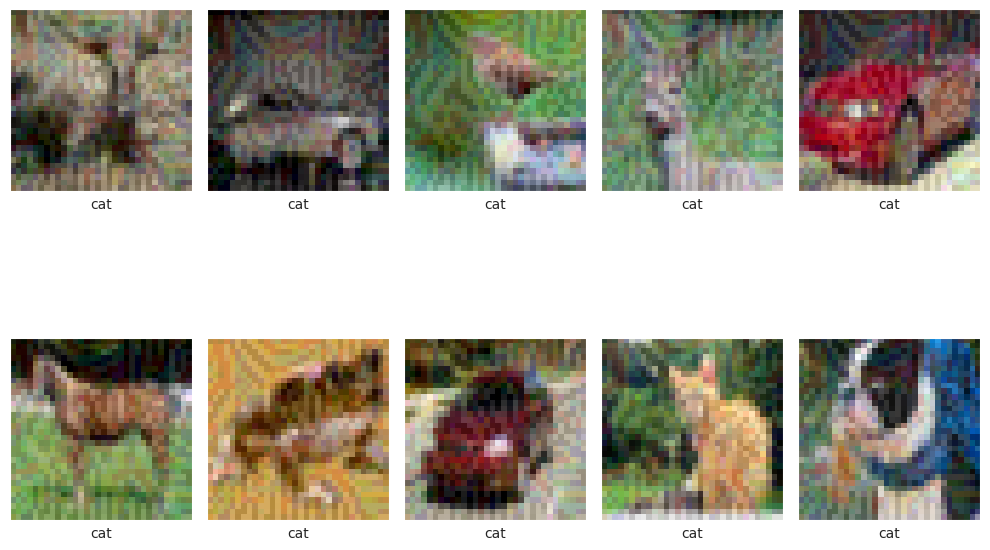


 *******Your marks for generating UAPs is 5. *******



In [27]:
# generate UAPs with the target label = 3 (cat)
UAP_l_inf = 0.06
UAP_target = 3

UAPs = generate_UAPs(
    target_model=target_model, x_arr=x_arr, y_arr=y_arr,
    UAP_target=UAP_target, UAP_l_inf=UAP_l_inf, exp_cfg=exp_cfg
)
UAPs = UAPs.unsqueeze(0)
assert target_model.training is False, "Your function should not change the training state."

# check the quality of UAPs
cal_UAP_l_inf = torch.abs(UAPs).max().item()
print(f"UAPs l_inf = {cal_UAP_l_inf:.2f}")
if cal_UAP_l_inf > UAP_l_inf + 1e-4:
    print("At least one adversarial example does not fulfill the requirement.")
    UAP_marks = 0
else:
    # get marks if achieving ceratin fooling rate
    UAP_attack = torch.clamp(x_arr + UAPs, min=0, max=1)
    with torch.no_grad():
        UAP_preds = target_model(utils.normalize(UAP_attack, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    UAP_fooling_rate = (UAP_preds == UAP_target).sum() / len(UAP_preds)
    UAP_fooling_rate = UAP_fooling_rate.item()
    print(f"UAPs fooling rate = {UAP_fooling_rate * 100:.1f}%")

    if UAP_fooling_rate > 0.90:
        UAP_marks = 5
    elif UAP_fooling_rate > 0.70:
        UAP_marks = 3
    elif UAP_fooling_rate > 0.50:
        UAP_marks = 1
    else:
        UAP_marks = 0

    utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=UAP_attack, labels_arr=UAP_preds, class_names=setup.CIFAR10_CLASSES)

print(f"\n *******Your marks for generating UAPs is {UAP_marks}. *******\n")

## Briefly describe how you implemented the UAPs. (2 marks)

Your answer: I implemented the uap bu learning a single perturbation that is added to all of the images and optimised to make the model predict a chosen target class. I first randomly initialised the perturbation within the bound then created a target label tensor where every image is assigned the same target class. During training i repeadedly applied the same perturbation to batches of images, clipped the results to keep the pixel values valid then i normalised them and passed them through the target model. I used cross entropy loss with the target labels and updated only the perturbation so it always stayed within the allowed constraint. this was repeated onver multiple batches so the perturbation learns to work across the full dataset rather than just the individual images. at the end the function outputs a single universal perturbation that can be added to the given images to pushc the models predictions toward the target class. 

In [33]:
# here is your final marks for the coding part
print(f"\n *******Your total marks for the coding part is {adv_marks + UAP_marks} / 11. *******\n")


 *******Your total marks for the coding part is 11 / 11. *******



# Optional Task: Adaptive Attack (Total: 2 bonus marks)

This is an optional task for CSIT375 students.
There are 2 bonus marks for this task.
These marks can be used to offset your lost marks in the previous tasks.
You are encouraged to complete this task to practice adaptive attacks.

You will implement adaptive attacks to bypass a defence.
You will use the same target model from Task 1.
However, this model is protected by a defence which crops random portions of an input image and resizes the portions back to the original size.
This is a white-box attack so that you have full access to the target model as well as the defence.

We only use 50 clean images to generate attack in this task. This saves computational time. You need to generate targeted adversarial examples for each image. Adversarial perturbations are constrained by $L_{∞}\le0.04$.

To generate adversarial examples, you need to implement the function **generate_adaptive_attack** in the corresponding cell below. Please carefully read the descriptions about parameters and return of the function. You have full access to the target model.

Marks:
- 1 mark if fooling rate > 90%.
- 0 marks otherwise.

Hint: the defence is stochastic. You can run your solution multiple times until you achieve the highest marks.

The defence strategy is implemented in **RobustModel** in the following cell.
You will find that the defence significantly lowers the accuracy of the target model. This is because the defence strategy was not included in data augmentation when training the target model. At the same time, you should also observe that this defence destroys the grex-box attacks you generated in Task 1.

We focus on adaptive attacks in this task. We will defeat this defence even though it introduces too much distortion for the target model. This demonstrates of power of adaptive attacks.

In [28]:
import torch.nn.functional as F
import torch.nn as nn

class RobustModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

        # random cropping as the defense
        self.transform = transforms.RandomResizedCrop(size=32, scale=(0.20, 0.50), antialias=True)

        # number of votes
        self.num_votes = 21

    def forward(self, x):
        # transform x multiple times and then the final output is the most voted one
        rlt_arr = []
        for _ in range(self.num_votes):
            trans_x = self.transform(x)
            logits = self.model(trans_x)
            preds = torch.argmax(logits, dim=1)
            rlt_arr.append(preds)

        rlt_arr = torch.stack(rlt_arr).transpose(0, 1)

        # the mode function returns the element with the highest count
        mode_val, mode_idx = torch.mode(rlt_arr, dim=1)

        # creat logits with the most voted one equal to 1 and the other logit values equal to 0
        # this is equivalent to one-hot encoding
        # note that this operation is not differentiable
        final_logits = F.one_hot(mode_val, num_classes=10).float()
        return final_logits

assert target_model.training is False
robust_model = RobustModel(target_model).to(exp_cfg.device)
robust_model.eval()

# evaluate the performance on clean testing data.
_, robust_acc, _ = model_trainer.ModelTrainer.eval_on_dset(robust_model, test_set)


evaluating test set: loss 2.04146; accuracy 0.4196;: 100%|██████████| 157/157 [00:26<00:00,  6.03it/s]


Run the following cell to evaluate this robust model against your previously generated adversarial examples.

You can skip this cell if you have not done Task 1 yet.

In [29]:
# This robust model should destroy your previously generated adversarial examples.
with torch.no_grad():
    adv_preds = robust_model(utils.normalize(adv_x, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
fooling_rate = (adv_preds == adv_target_arr).sum() / len(adv_target_arr)
print(f"Robust model: Task 1 grey-box adversarial examples fooling rate = {fooling_rate * 100:.1f}%")

Robust model: Task 1 grey-box adversarial examples fooling rate = 17.0%


Visualize how RandomResizedCrop works.

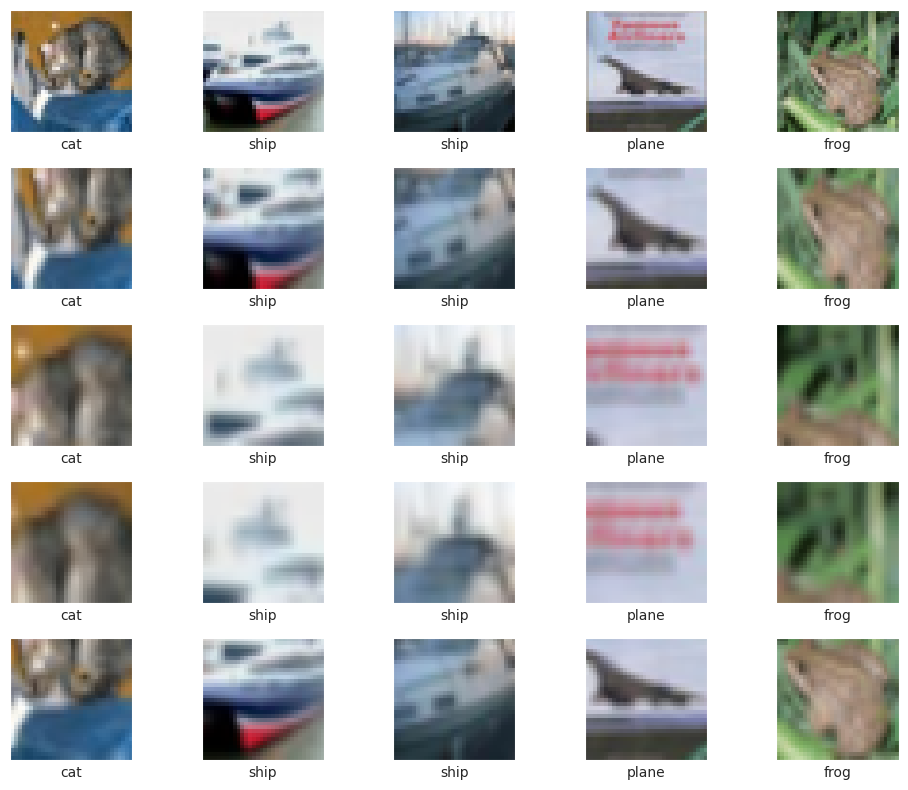

In [30]:
tmp_test_loader = torch.utils.data.DataLoader(test_set, batch_size=5, num_workers=0, shuffle=False)
for vis_x, vis_y in tmp_test_loader:
    vis_x = vis_x.to(exp_cfg.device)

    vis_arr = [vis_x]
    for _ in range(4):
        vis_trans_x = robust_model.transform(vis_x)
        vis_arr.append(vis_trans_x)

    vis_arr = torch.concatenate(vis_arr, dim=0)
    vis_arr = vis_arr * cifar10_std_tensor + cifar10_mean_tensor

    vis_y = torch.tile(vis_y, (5, ))
    utils.show_imgs_tensor(nrows=5, ncols=5, imgs_arr=vis_arr, labels_arr=vis_y,
                            class_names=setup.CIFAR10_CLASSES)

    # only plot 1 batch
    break

## Implement generate_adaptive_attack (1 bonus mark)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import utils


def generate_adaptive_attack(
        target_model: torch.nn.Module,
        x_arr: torch.Tensor,
        y_arr: torch.Tensor,
        adv_target_arr: torch.Tensor,
        adv_l_inf: float,
        exp_cfg,
) -> torch.Tensor:
    """
    target_model: the target model to attack
    x_arr: unnormalized clean images with shape [N, C, H, W].
    y_arr: ground truth labels with shape [N].
    adv_target_arr: the target labels of adversarial examples with shape [N].
    adv_l_inf: the allowed l_inf for all adversarial examples.
    exp_cfg: general configurations including out_dir, data_dir, device, etc.

    return: adversarial examples with shape [N, C, H, W] that can fool the target model.
    """

    #get the right device 
    device = exp_cfg.device
    #move inputs to the correct device
    x_arr = x_arr.to(device)
    y_arr = y_arr.to(device)
    adv_target_arr = adv_target_arr.to(device)
    #move cifar-10 normalization tensors to the same device
    mean = cifar10_mean_tensor.to(device)
    std = cifar10_std_tensor.to(device)

    #keep the target model in evaluation mode
    target_model.eval()

    #use the same random crop defence as robustmodel
    crop_transform = transforms.RandomResizedCrop(
        size=32,
        scale=(0.20, 0.50),
        antialias=True
    )

    def target_margin(logits, targets):
        #get the logit value of the target class
        target_logits = logits.gather(1, targets.unsqueeze(1)).squeeze(1)
        #get the largest logit among the non-target classes
        mask = F.one_hot(targets, num_classes=logits.shape[1]).bool()
        other_logits = logits.masked_fill(mask, float("-inf")).max(dim=1).values

        #return the gap between the target logit and the largest other logit
        return target_logits - other_logits

    def defended_logits_eot(x_input, num_votes=21):
        #apply the same random crop-resize process multiple times
        logits_list = []
        for _ in range(num_votes):
            x_norm = utils.normalize(x_input, mean, std)
            trans_x = crop_transform(x_norm)
            logits = target_model(trans_x)
            logits_list.append(logits)

        return torch.stack(logits_list, dim=0).mean(dim=0)

    #store the best adversarial example found for each image
    best_adv_x = x_arr.clone()
    best_margin = torch.full((len(x_arr),), -1e9, device=device)
    best_success = torch.zeros(len(x_arr), dtype=torch.bool, device=device)

    #attack settings
    num_restarts = 12
    num_steps = 120
    alpha = 1.0 / 255.0

    #use multiple restarts to improve the success of the atatck
    for restart_idx in range(num_restarts):
        #only continue attacking the images that keep failing
        active_mask = ~best_success
        if not active_mask.any():
            break

        cur_x = x_arr[active_mask]
        cur_targets = adv_target_arr[active_mask]

        #first restart starts from clean images then restarts use random start
        if restart_idx == 0:
            adv_x = cur_x.clone()
        else:
            rand_noise = torch.empty_like(cur_x).uniform_(-adv_l_inf, adv_l_inf)
            adv_x = torch.clamp(cur_x + rand_noise, min=0.0, max=1.0)

        #initialise momentum term
        momentum = torch.zeros_like(adv_x)

        #iterative adaptive pgd updates
        for _ in range(num_steps):
            adv_x.requires_grad_(True)

            #use eot over the same number of votes as the defence
            logits = defended_logits_eot(adv_x, num_votes=21)

            #cross entropy pushes predictions toward the target labels
            ce_loss = F.cross_entropy(logits, cur_targets)

            #negative target margin pushes the target logit above the others
            margin_loss = -target_margin(logits, cur_targets).mean()

            #combine both of the losses
            loss = ce_loss + margin_loss

            #clear the previous gradients
            target_model.zero_grad(set_to_none=True)
            if adv_x.grad is not None:
                adv_x.grad.zero_()

            #compute gradients with respect to the input
            loss.backward()

            #normalise gradients and update the momentum
            grad = adv_x.grad.detach()
            grad = grad / (grad.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-12)
            momentum = 0.9 * momentum + grad

            with torch.no_grad():
                #targeted pgd moves opposite to the gradient direction
                adv_x = adv_x - alpha * momentum.sign()

                #project perturbations back into the allowed l_inf range
                delta = torch.clamp(adv_x - cur_x, min=-adv_l_inf, max=adv_l_inf)

                #keep pixel values in the valid range
                adv_x = torch.clamp(cur_x + delta, min=0.0, max=1.0)

            adv_x = adv_x.detach()

        #evaluate this restart and keep the best result for each image
        with torch.no_grad():
            logits = defended_logits_eot(adv_x, num_votes=41)
            preds = logits.argmax(dim=1)
            cur_success = (preds == cur_targets)
            cur_margin = target_margin(logits, cur_targets)

            global_idx = torch.where(active_mask)[0]
            replace_mask = torch.zeros_like(cur_success)

            #replace if this restart is newly successful
            replace_mask |= cur_success & (~best_success[global_idx])

            #if already successful before keep the one with better target margin
            replace_mask |= cur_success & best_success[global_idx] & (cur_margin > best_margin[global_idx])

            #if still unsuccessful keep the stronger unsuccessful one
            replace_mask |= (~cur_success) & (~best_success[global_idx]) & (cur_margin > best_margin[global_idx])

            best_adv_x[global_idx[replace_mask]] = adv_x[replace_mask]
            best_margin[global_idx[replace_mask]] = cur_margin[replace_mask]
            best_success[global_idx[replace_mask]] = cur_success[replace_mask]

    return best_adv_x.detach()

The cell below will evaluate your implementations and print out your marks for this part.

Maximum l_inf = 0.04
50 adaptive adversarial examples fooling rate = 92.0%


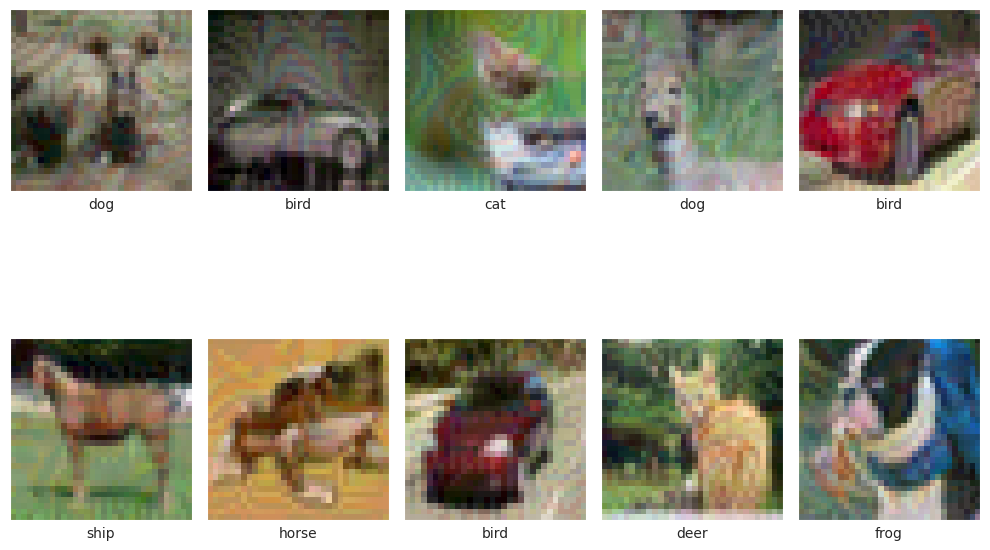


******* Your marks for generating adaptive adversarial examples is 1. *******



In [32]:
adaptive_num = 50
adaptive_adv_l_inf = 0.04
adaptive_adv_x = generate_adaptive_attack (
    target_model, x_arr=x_arr[:adaptive_num], y_arr=y_arr[:adaptive_num], adv_target_arr=adv_target_arr[:adaptive_num],
    adv_l_inf=adaptive_adv_l_inf, exp_cfg=exp_cfg
)
assert target_model.training is False, "Your function should not change the training state."

# check the quality of adaptive_adv_x
cal_adaptive_adv_l_inf = torch.abs(adaptive_adv_x - x_arr[:adaptive_num]).max().item()
print(f"Maximum l_inf = {cal_adaptive_adv_l_inf:.2f}")
if (cal_adaptive_adv_l_inf > adaptive_adv_l_inf + 1e-4) or (adaptive_adv_x.max().item() > 1.0) or (adaptive_adv_x.min().item() < 0.0):
    print("At least one adversarial example does not fulfill the requirement.")
    adaptive_adv_marks = 0
else:
    # get marks if achieving certain fooling rate
    with torch.no_grad():
        adaptive_adv_preds = robust_model(utils.normalize(adaptive_adv_x, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    assert len(adaptive_adv_preds) == adaptive_num

    fooling_rate = (adaptive_adv_preds == adv_target_arr[:adaptive_num]).sum() / adaptive_num
    fooling_rate = fooling_rate.item()
    print(f"{adaptive_num} adaptive adversarial examples fooling rate = {fooling_rate * 100:.1f}%")

    if fooling_rate > 0.90:
        adaptive_adv_marks = 1
    else:
        adaptive_adv_marks = 0

    utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=adaptive_adv_x, labels_arr=adaptive_adv_preds,
                            class_names=setup.CIFAR10_CLASSES)
print(f"\n******* Your marks for generating adaptive adversarial examples is {adaptive_adv_marks}. *******\n")

## Briefly describe how you implemented the adaptive attacks. (1 bonus mark)

Your answer: I implemented tha adaptive attack by directly attacking the defended target model while taking the random crop defence into account. since the defence applies stochastic random cropping and resizing many times before making the final decision, i used an expectation over transformation style approach where the same crop resize process is applied multiple times during each attack steps and the logits are averaged. to generate the attacks i used a targeted pgd style optimisation process with momentum and multuiple random restarts. For each step, i computed an eot loss made from cross entropy adn a target margin term, so that the attack pushes the model toward the target class while also making the target logit larger than the other logits. after each update i projected the perturnation bnack into the allowed range and clipped the adversarial images to keep the pixel values valid. I also kept track of the best adversarial example for each image across all restars and among the successful attacks i kept the one with the strongest target margin. 

# Submission

After running all cells in this notebook, click "File -> Download Notebook" to save this notebook as "assignment1-csit375.ipynb" locally.
Please open this file with Kaggle or another Python notebook editor (e.g., Colab) again to confirm that all the results are correctly shown.

For submission, you only need to submit **assignment1-csit375.ipynb**.

Zip this file into a single **zip** file (do NOT use .rar). Submit this zip file via Moodle by the due date and time. Assignments that are not submitted on Moodle will not be marked.